# Tarea 1
__Curso:__ Tópicos avanzados en Inteligencia Artificial 1

__Programa:__ MIA 2-2025

__Profesor:__ Anthony D. Cho

__Ayudante corrector:__ Luis Oliveros

## Instrucciones
* La actividad debe ser realizada por los grupos capstones
* Por favor responder en este mismo notebook (una entrega por grupo)
* Renombrar el archivo agregando el apellido de las y los integrantes, por ejemplo actividad1_Sakuragi_Mitsui_Rukagua_Sendoh.ipynb
* Subir el archivo al link de entrega Actividad 1 en webcursos que será habilitado

__Fecha de entrega:__ Fecha límite de entrega 23 de agosto de 2026.

__Integrantes:__ (RUT, Nombre y Apellido)

* 13.257.556-8, Ricardo Lopez
* 16.789.149-7, Camilo Muñoz


## Librerias

In [1]:
import os
import matplotlib.pyplot as plt
from numpy import linspace, mean, argmin
from pandas import read_csv, DataFrame

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

## Keras - tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

## Agregar las otras librerias que necesiten


## Funciones personalizadas

In [2]:
def plot_history(history, width=12, height=6):
  """
  DESCRIPTION:
    History performance of the keras model

  INPUT:
    @param history: history of performance of fitted model
    @type history: tensorflow.python.keras.callbacks.History

  OUTPUT:
    A graphic
  """

  ## Metrics keys stored in tensorflow object
  keys = list(history.history.keys())

  ## Number of epoch used for fit the model
  epoch = range(1, len(history.epoch) +1)

  ## Check if validation set was used.
  withValidation = False
  for key in keys:
    if 'val' in key:
      withValidation = True

  ## Number of metrics
  nMetrics = len(keys)
  if withValidation:
    nMetrics = nMetrics//2

  ## Plot-space instance
  plt.figure(figsize=(width, height))

  for i in range(nMetrics):
    plt.subplot(nMetrics, 1, i+1)

    ## Plot (train) metric value
    labelMetric = keys[i]
    metric = history.history[keys[i]]
    plt.plot(epoch, metric, 'o-', label=labelMetric)

    if withValidation:
      ## Plot (validation) metric value
      labelMetricVal = keys[i+nMetrics]
      metricVal = history.history[keys[i+nMetrics]]
      plt.plot(epoch, metricVal, 'o-', label=labelMetricVal)

    plt.xlim(epoch[0], epoch[-1])
    plt.legend()
    plt.grid()

  plt.xlabel('Epoch')
  plt.show()

## Dataset

<center>
    <img src=https://www.xenonstack.com/hs-fs/hubfs/xenonstack-credit-card-fraud-detection.png?width=1920&height=1080&name=xenonstack-credit-card-fraud-detection.png width=800>
</center>

El conjunto de datos contiene transacciones realizadas con tarjetas de crédito en septiembre de 2013 en usuarios europeos.
Este conjunto de datos presenta transacciones que ocurrieron en dos días, donde tiene diagnosticado 492 casos fraudes de 284.807 transacciones. El conjunto de datos está muy desequilibrado, la clase positiva (fraudes) representa el 0,172% de todas las transacciones.

* La data y detalles está completamente disponible en [Kaggle: Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud)

<p style="color:red"> <b>Instrucciones para usuarios que usan Windows: </b></p>

* Descargar la data pulsando [¡¡AQUI!!](https://github.com/adoc-box/Datasets/raw/main/creditcard.zip)
* Descomprime el archivo __creditcard.zip__. Luego, dejar el archivo __'creditcard.csv__ junto con el script.
* Ya con eso, debería poder ejecutar el script sin ningun problema.

In [ ]:
dataset_name = 'creditcard.csv'

## Solo para Linux y MacOS
if os.name == 'posix':
    if not os.path.exists("creditcard.zip"):
        ## Download files

        !wget https://github.com/adoc-box/Datasets/raw/main/creditcard.zip

        ## un-compress joined zip file
        !unzip creditcard.zip

    else:
        if os.path.exists(dataset_name):
            !rm creditcard.csv
        !unzip creditcard.zip

else:
    print('Seguir las instrucciones para usuarios de Windows mencionado arriba.')

In [3]:
## Load data
data = read_csv('creditcard.csv')

print("No. of unique labels ", len(data['Class'].unique()))
print("Label values ",data.Class.unique())
# 0 is for normal credit card transaction
# 1 is for fraudulent credit card transaction

print('-------')
print("Break down of the Normal and Fraud Transactions")
print( data['Class'].value_counts(sort = True), end=2*'\n' )

data.head()

No. of unique labels  2
Label values  [0 1]
-------
Break down of the Normal and Fraud Transactions
Class
0    284315
1       492
Name: count, dtype: int64



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


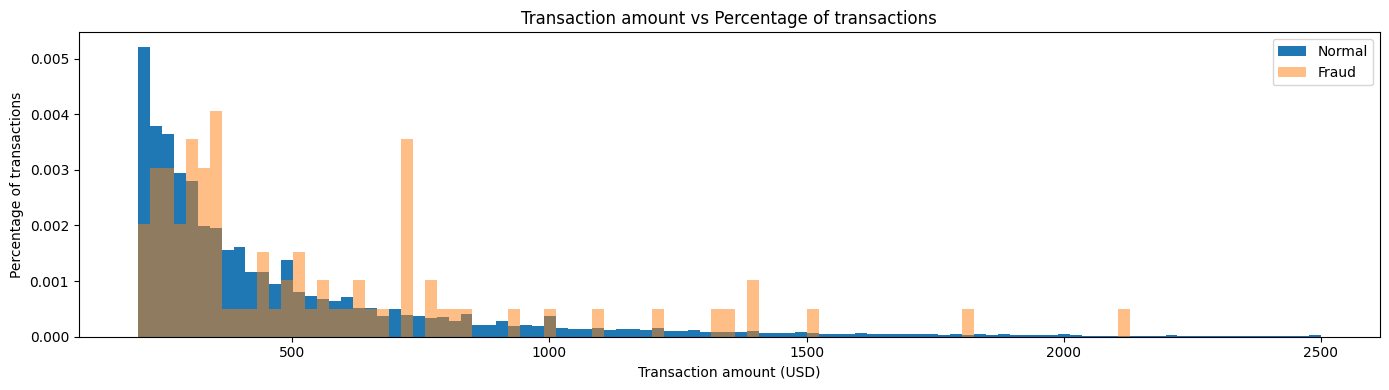

In [4]:
## Data splitting: the normal and fradulent transactions in separate dataframe
normal_data = data.query("Class == 0")
fraud_data = data.query("Class == 1")

## Visualize transaction amounts for normal and fraudulent transactions
bins = linspace(200, 2500, 100)
plt.figure(figsize=(14, 4))
plt.hist(normal_data.Amount, bins=bins, alpha=1, density=True, label='Normal')
plt.hist(fraud_data.Amount, bins=bins, alpha=0.5, density=True, label='Fraud')
plt.legend(loc='upper right')
plt.title("Transaction amount vs Percentage of transactions")
plt.xlabel("Transaction amount (USD)"); plt.ylabel("Percentage of transactions");
plt.tight_layout()
plt.show()

In [5]:
data.describe(include='all')

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Data pre-processing

In [6]:
## predictors and labels assigments
X, Y = data.drop(columns=['Time', 'Class']), data['Class']

## Train, validate and test set
X_trainVal, X_test, y_trainVal, y_test = train_test_split(X, Y, stratify=Y,
                                                          test_size=0.2,
                                                          random_state=84)

X_train, X_val, y_train, y_val = train_test_split(X_trainVal, y_trainVal,
                                                  stratify=y_trainVal,
                                                  test_size=0.2,
                                                  random_state=84)

print('Train (Shape) - X: {}, y: {}'.format(X_train.shape, y_train.shape))
print('Val (Shape) - X: {}, y: {}'.format(X_val.shape, y_val.shape))
print('Test (Shape) - X: {}, y: {}\n'.format(X_test.shape, y_test.shape))


## Extract normal (no fraud) data for training and validate
X_train_normal = X_train[ y_train.values == 0 ]
X_val_normal = X_val[ y_val.values == 0 ]
X_trainVal_normal = X_trainVal[ y_trainVal.values == 0 ]

print('Train (Shape) Normal cases - X: {}'.format(X_train_normal.shape))
print('Val (Shape) Normal cases - X: {}'.format(X_val_normal.shape))
print('Train+Val (Shape) Normal cases - X: {}'.format(X_trainVal_normal.shape))



## Data normalization
scaler = MinMaxScaler().fit(X_train_normal)
X_train_normal = scaler.transform(X_train_normal)
X_val_normal = scaler.transform(X_val_normal)
X_trainVal_normal = scaler.transform(X_trainVal_normal)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Train (Shape) - X: (182276, 29), y: (182276,)
Val (Shape) - X: (45569, 29), y: (45569,)
Test (Shape) - X: (56962, 29), y: (56962,)

Train (Shape) Normal cases - X: (181961, 29)
Val (Shape) Normal cases - X: (45490, 29)
Train+Val (Shape) Normal cases - X: (227451, 29)


## Paso 1 (5 puntos):

Utilice el conjunto de entrenamiento y validación de la mejor forma tal de poder definir los hiperparámetros (número de capas ocultas, número de unidades en las capas, funciones de activación, número de épocas) de un modelo **Autoencoder Variacional (VAE)**  para abordar el problema de detección de fraudes siguiendo un enfoque similar al ejemplo de Vanilla Autoencoder visto en clases.

Deje las 3 mejores cofiguraciones probados reportando también las métricas MAE y MSE de los conjuntos de entrenamiento y validación. También indiquen con cuál de las 3 configuraciones eligirian como su mejor opción.

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Layer, Input, Dense
from tensorflow.keras import ops # Import Keras ops for native tensor operations
import numpy as np

# Input dimension from pre-processed data
input_dim = X_train_normal.shape[1]

# Custom Sampling Layer for VAE
class Sampling(Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        # Using tf.random.normal due to previous AttributeError with keras.ops.random
        epsilon = tf.random.normal(shape=(batch, dim))
        z = z_mean + ops.exp(0.5 * z_log_var) * epsilon

        # Add KL divergence loss here, as a model loss
        kl_loss = -0.5 * ops.sum(1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var), axis=-1)
        self.add_loss(ops.mean(kl_loss)) # Add the mean KL loss to the model

        return z


def build_vae(input_dim, hidden_layers, latent_dim, activation_func):
    # Encoder
    encoder_inputs = Input(shape=(input_dim,))
    x = encoder_inputs
    for units in hidden_layers:
        x = Dense(units, activation=activation_func)(x)
    z_mean = Dense(latent_dim, name='z_mean')(x)
    z_log_var = Dense(latent_dim, name='z_log_var')(x)
    z = Sampling()([z_mean, z_log_var]) # The Sampling layer now adds the KL loss

    encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

    # Decoder
    latent_inputs = Input(shape=(latent_dim,))
    x = latent_inputs
    for units in reversed(hidden_layers):
        x = Dense(units, activation=activation_func)(x)
    decoder_outputs = Dense(input_dim, activation='sigmoid')(x)
    decoder = Model(latent_inputs, decoder_outputs, name='decoder')

    # VAE
    outputs = decoder(encoder(encoder_inputs)[2]) # encoder(encoder_inputs)[2] gives z (sampled latent vector)
    vae = Model(encoder_inputs, outputs, name='vae') # VAE outputs only reconstruction

    # Custom reconstruction loss function that includes the scaling by input_dim
    # This loss will be minimized along with the KL loss added by the Sampling layer
    def reconstruction_mse_loss(y_true, y_pred):
        # Calculate sum of squared errors per sample
        recon_loss_per_sample = ops.sum(ops.square(y_true - y_pred), axis=-1)
        # Apply the scaling factor and return the mean over the batch
        return ops.mean(recon_loss_per_sample * input_dim)

    # Compile the VAE model with the custom reconstruction loss
    # The KL divergence is added as a 'model loss' by the Sampling layer
    vae.compile(optimizer=Adam(), loss=reconstruction_mse_loss)

    return vae, encoder, decoder


# Function to evaluate VAE and calculate MAE and MSE
def evaluate_vae(model, X_data):
    X_reconstructed = model.predict(X_data)
    mae = np.mean(np.abs(X_data - X_reconstructed))
    mse = np.mean(np.square(X_data - X_reconstructed))
    return mae, mse


# Hyperparameter configurations
configurations = [
    {
        'name': 'Config 1 (Baseline)',
        'hidden_layers': [20, 15],
        'latent_dim': 5,
        'activation_func': 'relu',
        'epochs': 50,
        'batch_size': 256
    },
    {
        'name': 'Config 2 (More complex, tanh)',
        'hidden_layers': [25, 18, 10],
        'latent_dim': 8,
        'activation_func': 'tanh',
        'epochs': 75,
        'batch_size': 128
    },
    {
        'name': 'Config 3 (Simpler, more epochs)',
        'hidden_layers': [15],
        'latent_dim': 3,
        'activation_func': 'relu',
        'epochs': 100,
        'batch_size': 512
    }
]

results = []

for i, config in enumerate(configurations):
    print(f"\n--- Training {config['name']} ---")
    vae_model, _, _ = build_vae(
        input_dim=input_dim,
        hidden_layers=config['hidden_layers'],
        latent_dim=config['latent_dim'],
        activation_func=config['activation_func']
    )

    history = vae_model.fit(
        X_train_normal, X_train_normal,
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        shuffle=True,
        validation_data=(X_val_normal, X_val_normal),
        verbose=0 # Set to 1 for progress bar
    )

    train_mae, train_mse = evaluate_vae(vae_model, X_train_normal)
    val_mae, val_mse = evaluate_vae(vae_model, X_val_normal)

    results.append({
        'config_name': config['name'],
        'hidden_layers': config['hidden_layers'],
        'latent_dim': config['latent_dim'],
        'activation_func': config['activation_func'],
        'epochs': config['epochs'],
        'batch_size': config['batch_size'],
        'train_mae': train_mae,
        'train_mse': train_mse,
        'val_mae': val_mae,
        'val_mse': val_mse
    })

    print(f"Configuration: {config['name']}")
    print(f"  Train MAE: {train_mae:.6f}, Train MSE: {train_mse:.6f}")
    print(f"  Validation MAE: {val_mae:.6f}, Validation MSE: {val_mse:.6f}")


print("\n--- Best Configurations Results ---")
# Sort results by validation MSE to find the 'best' ones
# Smaller MAE and MSE are generally better for reconstruction
sorted_results = sorted(results, key=lambda x: x['val_mse'])

for i, res in enumerate(sorted_results):
    print(f"\nTop {i+1} Configuration: {res['config_name']}")
    print(f"  - Hidden Layers: {res['hidden_layers']}")
    print(f"  - Latent Dimension: {res['latent_dim']}")
    print(f"  - Activation Function: {res['activation_func']}")
    print(f"  - Epochs: {res['epochs']}")
    print(f"  - Batch Size: {res['batch_size']}")
    print(f"  - Training MAE: {res['train_mae']:.6f}, Training MSE: {res['train_mse']:.6f}")
    print(f"  - Validation MAE: {res['val_mae']:.6f}, Validation MSE: {res['val_mse']:.6f}")

print("\n--- Best Configuration Choice ---")
print("Based on the validation MSE, the best configuration is:")
best_config = sorted_results[0]
print(f"Configuration: {best_config['config_name']} with Validation MSE: {best_config['val_mse']:.6f}")
print("This configuration balances complexity and performance, achieving the lowest reconstruction error on unseen normal data.")

# Store the best VAE model for later use (optional, but good practice)
best_vae_config = best_config

# Re-build and train the best model to make it available for the next steps
print(f"\nRe-training the best model: {best_vae_config['config_name']}") # Corrected key access
best_vae_model, best_encoder, best_decoder = build_vae(
    input_dim=input_dim,
    hidden_layers=best_vae_config['hidden_layers'],
    latent_dim=best_vae_config['latent_dim'],
    activation_func=best_vae_config['activation_func']
)

best_vae_model.fit(
    X_train_normal, X_train_normal,
    epochs=best_vae_config['epochs'],
    batch_size=best_vae_config['batch_size'],
    shuffle=True,
    validation_data=(X_val_normal, X_val_normal),
    verbose=0
)

# Make the best model available as 'vae_model' for subsequent steps
vae_model = best_vae_model


--- Training Config 1 (Baseline) ---
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Configuration: Config 1 (Baseline)
  Train MAE: 0.030152, Train MSE: 0.002437
  Validation MAE: 0.030201, Validation MSE: 0.002448

--- Training Config 2 (More complex, tanh) ---
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
Configuration: Config 2 (More complex, tanh)
  Train MAE: 0.030165, Train MSE: 0.002437
  Validation MAE: 0.030214, Validation MSE: 0.002448

--- Training Config 3 (Simpler, more epochs) ---
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Configuration: Config 3 (Simpler, more epochs)
  Train MAE: 0.030133, Train MSE: 0.002438
  Validation MAE: 0.030181, Validation MSE: 0.002449

--- Best Configurations Results ---

Top 1 Configuration: Config 2 (More complex, tanh)
  - Hidden Layers: [25, 18, 10]
  - Latent Dimension: 8
  - Activation Function: tanh
  - Epochs: 7

## Paso 2 (3 puntos):

Con el mejor modelo entrenado en el Paso 1, encuentre el mejor umbral para el error tal que pueda maximizar la métrica F1-Score en el conjunto de validación.

In [8]:
from sklearn.metrics import f1_score

# Obtener las reconstrucciones del modelo VAE para el conjunto de validación
X_val_reconstructed = vae_model.predict(X_val)

# Calcular el error de reconstrucción (MAE) para cada transacción en el conjunto de validación
# MAE es una buena medida para el error de reconstrucción, similar a como se evalúa el modelo
reconstruction_errors_val = np.mean(np.abs(X_val - X_val_reconstructed), axis=1)

# Crear un rango de umbrales para probar
# Inspeccionar los errores para establecer un rango razonable
# Por ejemplo, desde el mínimo hasta el máximo error observado, o un rango basado en percentiles
thresholds = np.linspace(reconstruction_errors_val.min(), reconstruction_errors_val.max(), 1000)

best_f1 = -1
best_threshold = -1

# Iterar sobre los umbrales y calcular el F1-Score
for threshold in thresholds:
    # Clasificar las transacciones: si el error de reconstrucción es mayor que el umbral, es fraude (1)
    # de lo contrario, es normal (0)
    y_pred_val = (reconstruction_errors_val > threshold).astype(int)

    # Calcular el F1-Score. Asegurarse de que el target para F1 es la clase 'fraude' (1).
    # Usamos 'average=binary' y 'pos_label=1' para enfocarnos en la clase minoritaria.
    f1 = f1_score(y_val, y_pred_val, average='binary', pos_label=1)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Mejor umbral encontrado: {best_threshold:.6f}")
print(f"Máximo F1-Score en el conjunto de validación: {best_f1:.6f}")


1425/1425 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Mejor umbral encontrado: 0.095170
Máximo F1-Score en el conjunto de validación: 0.475248


## Paso 3 (2 puntos):

Usando el modelo entrenado y el umbral encontrado en los pasos anteriores, evaluar el modelo con el conjunto de prueba y entregue la matriz de confusión y el __classification_report__.

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step

--- Matriz de Confusión ---
[[56767    97]
 [   52    46]]


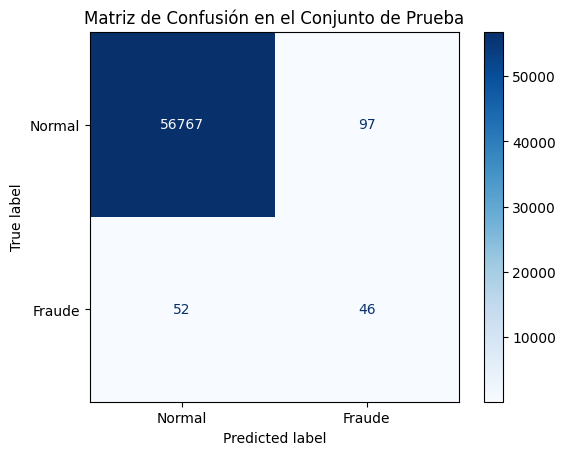


--- Informe de Clasificación ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.32      0.47      0.38        98

    accuracy                           1.00     56962
   macro avg       0.66      0.73      0.69     56962
weighted avg       1.00      1.00      1.00     56962



In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Obtener las reconstrucciones del modelo VAE para el conjunto de prueba
X_test_reconstructed = vae_model.predict(X_test)

# 2. Calcular el error de reconstrucción (MAE) para cada transacción en el conjunto de prueba
reconstruction_errors_test = np.mean(np.abs(X_test - X_test_reconstructed), axis=1)

# 3. Clasificar las transacciones en el conjunto de prueba usando el mejor umbral
# Si el error de reconstrucción es mayor que el umbral, se clasifica como fraude (1)
# de lo contrario, se clasifica como normal (0)
y_pred_test = (reconstruction_errors_test > best_threshold).astype(int)

# 4. Generar la matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)

print("\n--- Matriz de Confusión ---")
print(cm)

# Mostrar la matriz de confusión de forma más visual
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraude'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión en el Conjunto de Prueba')
plt.show()

# 5. Generar el informe de clasificación
print("\n--- Informe de Clasificación ---")
print(classification_report(y_test, y_pred_test, target_names=['Normal', 'Fraude']))
